# NYC Taxi Rides EDA

## Analyze taxi rides to identify:
- rush hour patterns
- most common destinations and starting points
- weekday ride behaviour
- fare and tip trends

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# loading February 2025 data
taxi_data_jan = pd.read_parquet('yellow_tripdata_2025-02.parquet')

locations = pd.read_csv('locations.csv', delimiter=';').set_index('LocationID')

# function to add borough names to the dataset

def add_borough_name(df, borough_map) -> pd.DataFrame:
    """
    The function adds two columns, Start_borough and End_borough, to a selected dataframe. It maps borough IDs from the original dataframe with a mapping object 'borough_map'.
    """
    df = df.copy()
    df['Start_borough'] = df['PULocationID'].map(borough_map)
    df['End_borough'] = df['DOLocationID'].map(borough_map)
    return df

# mapping location names with their IDs in taxi_data dataframe

boroughs = locations['Borough']
taxi_data_jan = add_borough_name(taxi_data_jan, boroughs)

# calculating trip duration
taxi_data_jan['trip_duration'] = taxi_data_jan['tpep_dropoff_datetime'] - taxi_data_jan['tpep_pickup_datetime']

## Data cleaning

Removed:
- invalid trip durations
- unknown boroughs
- extreme fares
- impossible or improbable passenger counts

In [20]:

# cleaning data
taxi_data_jan['Start_borough'] = taxi_data_jan['Start_borough'].replace('Unknown', np.nan)
taxi_data_jan['End_borough'] = taxi_data_jan['End_borough'].replace('Unknown', np.nan)

taxi_data_jan = taxi_data_jan[
    (taxi_data_jan['trip_distance'] > 0) # deleting rides with no distance
    & (taxi_data_jan['total_amount'] > 0) # deleting free rides
    & (taxi_data_jan['trip_duration'] > pd.Timedelta(minutes=1)) # deleting rides lasting shorter than 1 minute
    & (taxi_data_jan['trip_duration'] < pd.Timedelta(hours=3)) # removing rides longer than 3 hours
    & (taxi_data_jan['passenger_count'] > 0) # removing rides with no passengers
    & (taxi_data_jan['passenger_count'] <= 6) # removing rides with too many passengers (more than that would not fit in a regular or SUV cab)
    & (taxi_data_jan['total_amount'] > 2) # deleting very cheap rides
    & (taxi_data_jan['total_amount'] < 300) # deleting very expensive rides
    & (taxi_data_jan['Start_borough'].notna()) # excluding unknown boroughs
    & (taxi_data_jan['End_borough'].notna())] 

# adding names of the days as Categoricals
weekdays_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
taxi_data_jan['day_of_the_week'] = pd.Categorical(taxi_data_jan['tpep_dropoff_datetime'].dt.day_name(), categories = weekdays_ordered, ordered = True)

# destinations most frequently chosen in rush hours (drop-off time 7:00 - 9:00 in Mon-Fri)
rush_hour_drives = taxi_data_jan[taxi_data_jan['tpep_dropoff_datetime'].dt.hour.isin([7, 8])].copy() # filtering out rides only in rush hours (7-9)

rush_hour_drives['is_workday'] = (rush_hour_drives['tpep_dropoff_datetime'].dt.dayofweek < 5) # rides only in working days

rush_hour_dest = rush_hour_drives[rush_hour_drives['is_workday'] == True].groupby('End_borough').size().sort_values(ascending = False).head() # top 5 destinations during rush hours in working days
rush_hour_start = rush_hour_drives[rush_hour_drives['is_workday'] == True].groupby('Start_borough').size().sort_values(ascending = False).head() # top 5 starting points in rush hours in working days

# when are there the most cab rides in NYC?
highest_traffic_per_day = taxi_data_jan.groupby('day_of_the_week')['total_amount'].count()

# an average fare per weekday
daily_stats = taxi_data_jan.groupby('day_of_the_week').agg({'total_amount':'sum', 'trip_distance':'sum'})
avg_fare_per_mile = daily_stats['total_amount']/daily_stats['trip_distance']

# an average tip per weekday
avg_tip_per_day = taxi_data_jan.groupby('day_of_the_week')['tip_amount'].mean()

# an average distance covered per hour
avg_dst_per_hour = taxi_data_jan.groupby(taxi_data_jan['tpep_dropoff_datetime'].dt.hour)['trip_distance'].mean()


## Charts

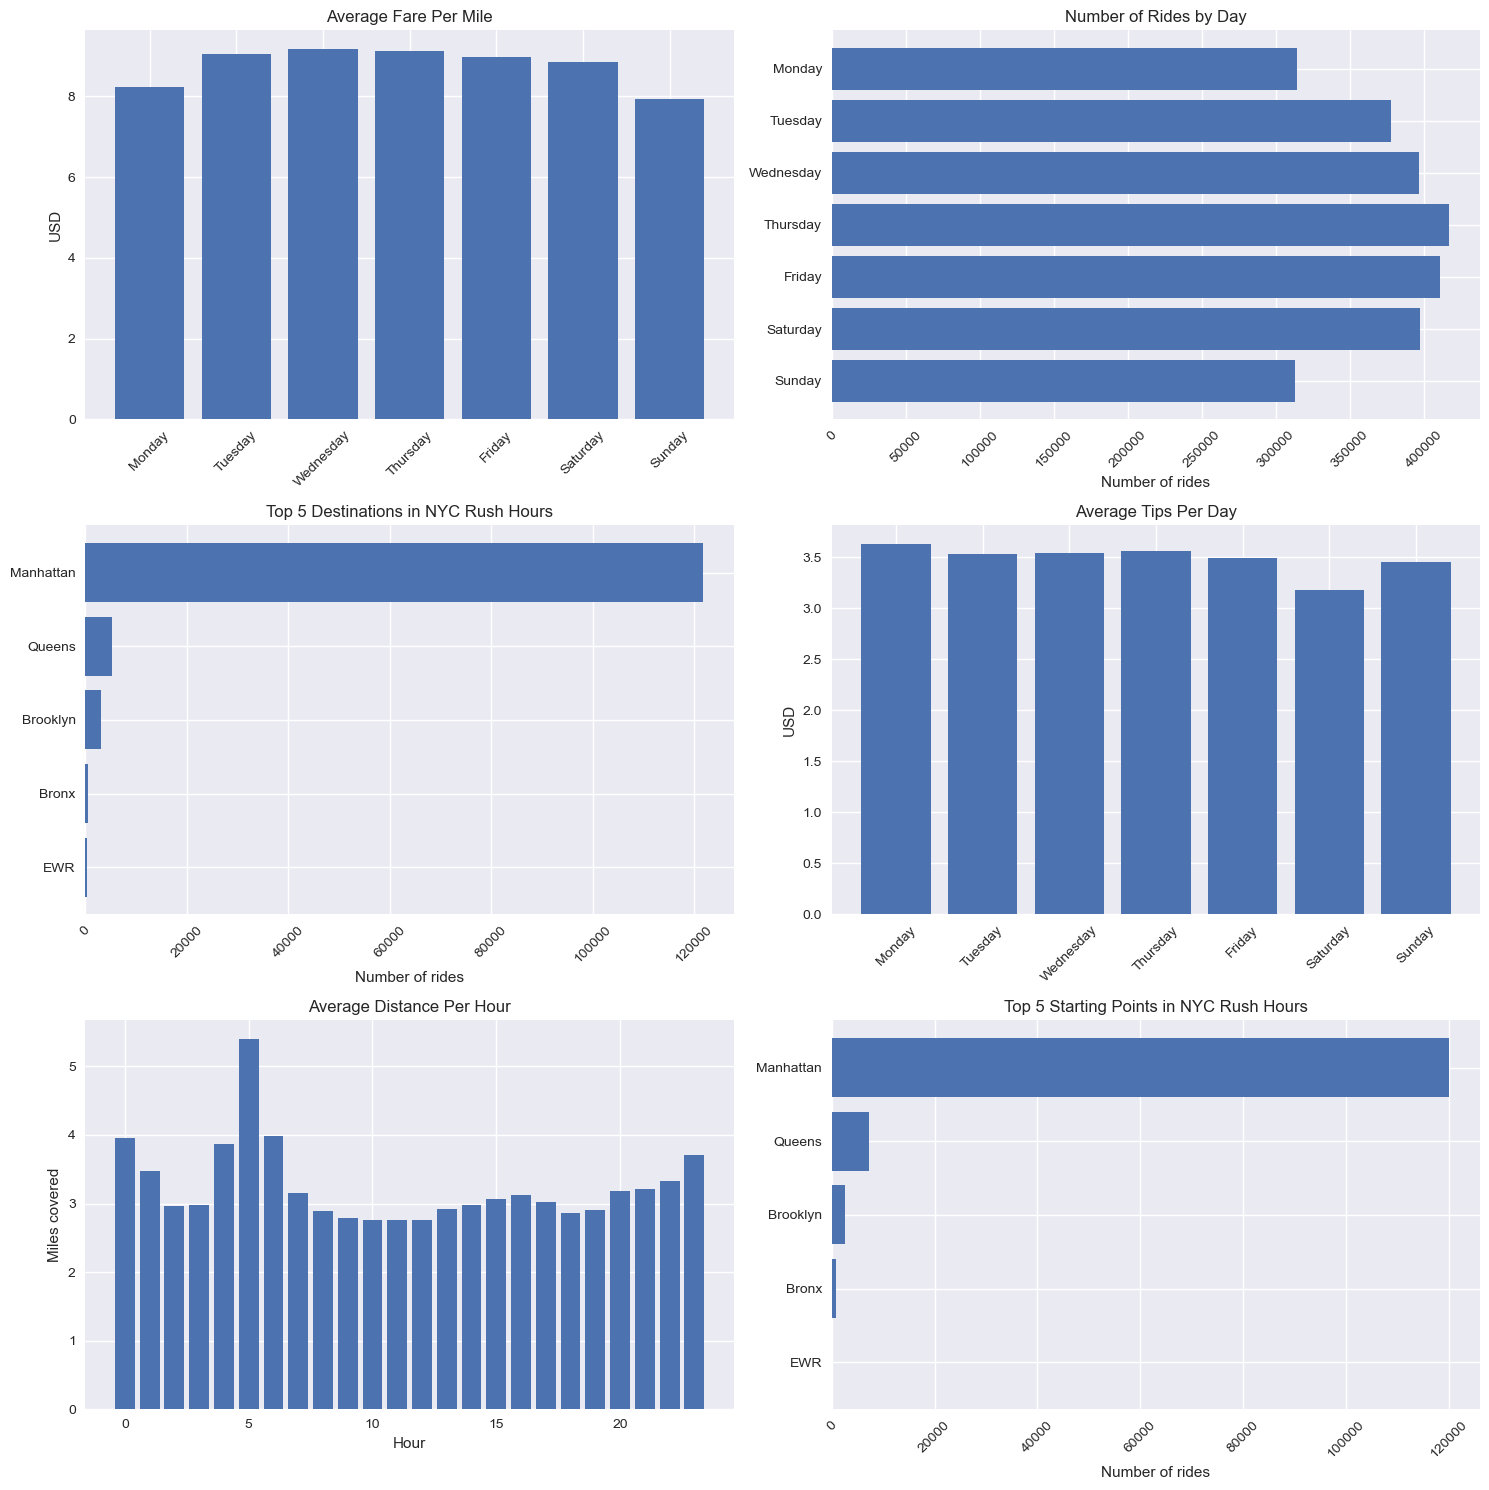

In [21]:
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(3 , 2, figsize = (15, 15))
axs[0, 0].bar(avg_fare_per_mile.index, avg_fare_per_mile.values)
axs[0, 0].tick_params(axis = 'x', rotation = 45)
axs[0, 0].set_title('Average Fare Per Mile')
axs[0, 0].set_ylabel('USD')

axs[0, 1].barh(highest_traffic_per_day.index, highest_traffic_per_day.values)
axs[0, 1].tick_params(axis = 'x', rotation = 45)
axs[0, 1].set_title('Number of Rides by Day')
axs[0, 1].invert_yaxis()
axs[0, 1].set_xlabel('Number of rides')

axs[1, 0].barh(rush_hour_dest.index, rush_hour_dest.values)
axs[1, 0].tick_params(axis = 'x', rotation = 45)
axs[1, 0].set_title('Top 5 Destinations in NYC Rush Hours')
axs[1, 0].invert_yaxis()
axs[1, 0].set_xlabel('Number of rides')

axs[1, 1].bar(avg_tip_per_day.index, avg_tip_per_day.values)
axs[1, 1].tick_params(axis = 'x', rotation = 45)
axs[1, 1].set_title('Average Tips Per Day')
axs[1, 1].set_ylabel('USD')

axs[2, 0].bar(avg_dst_per_hour.index, avg_dst_per_hour.values)
axs[2, 0].set_title('Average Distance Per Hour')
axs[2, 0].set_ylabel('Miles covered')
axs[2, 0].set_xlabel('Hour')

axs[2, 1].barh(rush_hour_start.index, rush_hour_start.values)
axs[2, 1].tick_params(axis = 'x', rotation = 45)
axs[2 ,1].set_title('Top 5 Starting Points in NYC Rush Hours')
axs[2, 1].invert_yaxis()
axs[2, 1].set_xlabel('Number of rides')

plt.tight_layout()
plt.show()

## Key insights

- Thursday has the highest number of rides. This may be correlated to people's preferences and arrangements regarding hybrid work, where employees are more likely to stay at home at the beginning of a week and commute more often on Wednesdays, Thursdays and Fridays. However, this hypothesis requires some additional external data sources.
- Manhattan is both the main destination and starting point during rush hours. This suggests that substantial share of taxi traffic during peak commuting periods occurs within Manhattan itself, highlighting the borough's role as the main business and commercial hub of New York City. 
- The longest rides happen mostly in late-night and early-morning hours, with the peak at 5 AM. This may be attributable to airport_related traffic, especially rides to and from Newark Liberty International Airport. These usually involve longer travel distances compared to intra-city commutes.
- An average fare per mile as well as an average tip per day remain fairly consistent throughout the whole week. This indicates that the pricing and tipping behaviour do not vary significantly during business days and weekends.